# Modeling

**Project:** Airbnb Pricing Analysis

**Team:** Jessie Dicker, Norma Arredondo

**Date:** April 19, 2026




## Table of Contents
1. Load Data
2. All Models - Default Parameters
3. Cross-Validation
4. Hyperparameter Tuning - GridSearch CV
5. Final Model Comparison
6. Save Best Model
7. Key Findings Summary

In [1]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## settings
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

## 1. Load Data
Load the CSV files from Notebook 3.

In [3]:
# load data from feature engineering notebook
X_train = pd.read_csv('../data/modeling/X_train.csv')
X_test = pd.read_csv('../data/modeling/X_test.csv')
y_train = pd.read_csv('../data/modeling/y_train.csv').squeeze()
y_test = pd.read_csv('../data/modeling/y_test.csv').squeeze()

## save WITH SCALE
X_train_standard = pd.read_csv('../data/modeling/X_train_standard.csv')
X_test_standard = pd.read_csv('../data/modeling/x_test_standard.csv')

print('Shapes\n')
print(f'Training (baseline): {X_train_base.shape}')
print(f'Training (original): {X_train.shape}')
print(f'Training (Standard): {X_train_standard.shape}')
print(f'Test:                {X_test.shape}')

Shapes

Training (baseline): (39107, 10)
Training (original): (39107, 235)
Training (Standard): (39107, 11)
Test:                (9777, 235)


In [4]:
# Confirm Column Alignment
assert list(X_train.columns) == list(X_test.columns), \
    "Column mismatch between X_train and X_test"
assert list(X_train_standard.columns) == list(X_test_standard.columns), \
    "Column mismatch between X_train_standard and X_test_standard"

print("Column alignment confirmed for unscaled sets")
print("Column alignment confirmed for scaled sets")

Column alignment confirmed for unscaled sets
Column alignment confirmed for scaled sets


In [5]:
# Check Target Distribution and range
print('y_train distribution:')
print(y_train.describe().round(2))

print('\ny_test distribution:')
print(y_test.describe().round(2))

print('\nTarget Range:')
print(f"\ny_train range: ${int(y_train.min())} — ${int(y_train.max())}")
print(f"y_test range: ${int(y_test.min())} — ${int(y_test.max())}")

y_train distribution:
count    39107.00
mean       151.63
std        225.58
min         10.00
25%         69.00
50%        105.00
75%        175.00
max      10000.00
Name: price, dtype: float64

y_test distribution:
count     9777.00
mean       157.24
std        291.29
min         10.00
25%         69.00
50%        109.00
75%        179.00
max      10000.00
Name: price, dtype: float64

Target Range:

y_train range: $10 — $10000
y_test range: $10 — $10000


In [6]:
# Outliers were found in price
## Cap target variable at 99th percentile of training data
price_cap = y_train.quantile(0.99)
print(f'99th percentile price cap: ${price_cap:.0f}')

y_train_capped = y_train.clip(upper=price_cap)
y_test_capped = y_test.clip(upper=price_cap)


print(f'Original y_train max: ${y_train.max():.2f}')
print(f'Capped y_train max:   ${y_train_capped.max():.2f}')
print(f'\nOriginal y_test max: ${y_test.max():.2f}')
print(f'Capped y_test max:   ${y_test_capped.max():.2f}')

print(f"Rows affected in train: {(y_train > price_cap).sum()}")
print(f"Rows affected in test:  {(y_test > price_cap).sum()}")

99th percentile price cap: $794
Original y_train max: $10000.00
Capped y_train max:   $793.76

Original y_test max: $10000.00
Capped y_test max:   $793.76
Rows affected in train: 392
Rows affected in test:  107


There are outliers in our target variable, `price`, so we decided to cap the target variable at the 99th percentile to avoid any negative R² scores. The cap is fit on y_train and y_test. 
 

In [7]:
# print new Target distribution and range
print('New y_train distribution:')
print(y_train_capped.describe().round(2))

print('\nNew y_test distribution:')
print(y_test_capped.describe().round(2))

print('\nNewTarget Range:')
print(f"\ny_train range: ${int(y_train_capped.min())} — ${int(y_train_capped.max())}")
print(f"y_test range: ${int(y_test_capped.min())} — ${int(y_test_capped.max())}")

New y_train distribution:
count    39107.00
mean       143.39
std        120.87
min         10.00
25%         69.00
50%        105.00
75%        175.00
max        793.76
Name: price, dtype: float64

New y_test distribution:
count    9777.00
mean      146.13
std       124.68
min        10.00
25%        69.00
50%       109.00
75%       179.00
max       793.76
Name: price, dtype: float64

NewTarget Range:

y_train range: $10 — $793
y_test range: $10 — $793


### Observations 


- **Shapes:**

  X_train: (39107, 235) and X_test: (9777, 235)

  
- **Original Target Range (before capping):**


  y_train range is between 10 and 10,000

  y_test range is between 10 and 10,000


- **New Target Range (after capping):**

  y_train range is between 10 and 793

  y_test range is between 10 and 793


  
- **Scaled vs. Unscaled for each model type:**


  Linear Regression -> Scaled and Unscaled Data 

  Ridge Regression -> Scaled Data

  Lasso Regression -> Scaled Data

  Decision Tree -> Unscaled Data

  Random Forest -> Unscaled Data


The shapes of X_train and X_test are the same as those in Notebook 3. Capping the `price` was necessary to avoid a negative R² that affects the models. After capping, the Target Range changed. Throughout the Notebook, we will use the capped data set. 


## 2. All Models - Default Parameters

Use different fitting models to train, predict, and print metrics. 

In [8]:
# store results
results = []

### Model 1: Linear Regression 
Both unscaled and scaled data are used

#### Data in Feature Engineering (Unscaled)

In [9]:
# import linear regression
from sklearn.linear_model import LinearRegression

lr_fe = LinearRegression()
lr_fe.fit(X_train, y_train_capped)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
# linear regression (unscaled) train metrics
y_train_pred_lrfe = lr_fe.predict(X_train)

In [11]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2_train_lrfe = r2_score(y_train_capped, y_train_pred_lrfe)
rmse_train_lrfe = np.sqrt(mean_squared_error(y_train_capped, y_train_pred_lrfe))

print(f'No Scaling Linear Regression on train test: R² = {r2_train_lrfe:.4f}, RMSE = {rmse_train_lrfe:.4f}')


No Scaling Linear Regression on train test: R² = 0.3682, RMSE = 96.0727


In [12]:
# linear regression (unscaled) test metrics
y_pred_lrfe = lr_fe.predict(X_test)

In [13]:
r2_lrfe = r2_score(y_test_capped, y_pred_lrfe)
rmse_lrfe = np.sqrt(mean_squared_error(y_test_capped, y_pred_lrfe))

# store both train and test metrics
results.append({'Model': 'No Scaling Linear Regression', 'Train R²': r2_train_lrfe, 'Test R²': r2_lrfe,
                'Train RMSE': rmse_train_lrfe, 'Test RMSE': rmse_lrfe})

print(f'No Scaling Linear Regression on test set: R² = {r2_lrfe:.4f}, RMSE = {rmse_lrfe:.4f}')

No Scaling Linear Regression on test set: R² = 0.3514, RMSE = 100.4063


#### Data in Feature Engineering with Scale

In [14]:
# use scale data
lr = LinearRegression()
lr.fit(X_train_standard, y_train_capped)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
# linear regression with scale train metrics
y_train_pred_lr = lr.predict(X_train_standard)

In [16]:
# train R² and RMSE
r2_train_lr = r2_score(y_train_capped, y_train_pred_lr)
rmse_train_lr = np.sqrt(mean_squared_error(y_train_capped, y_train_pred_lr))

print(f'Linear Regression with Scale on train set: R² = {r2_train_lr:.4f}, RMSE = {rmse_train_lr:.4f}')

Linear Regression with Scale on train set: R² = 0.1721, RMSE = 109.9760


In [17]:
# linear regression with scale test metrics
y_pred_lr = lr.predict(X_test_standard)

In [18]:
# test R² and RMSE
r2_lr  = r2_score(y_test_capped, y_pred_lr )
rmse_lr  = np.sqrt(mean_squared_error(y_test_capped, y_pred_lr ))

results.append({'Model': 'Scaling Linear Regression','Train R²': r2_train_lr, 'Test R²': r2_lr,
                'Train RMSE': rmse_train_lr, 'Test RMSE': rmse_lr})

print(f'Linear Regression with Scale on test set: R² = {r2_lr :.4f}, RMSE = {rmse_lr :.4f}')

Linear Regression with Scale on test set: R² = 0.1662, RMSE = 113.8443


#### Linear Regression Observation

| Model | Train R² | Test  R² |  Train RMSE | Test RSME |
| -------- | -------- | -------- | -------- | -------- |
| No Scaling Linear Regression | 0.3682 | 0.3514 | 96.0727 | 100.4063 |
| Linear Regression with Scale | 0.1721 | 0.1662 | 109.9760 | 113.8443 |


There is a 0.017 difference in the R² gap for the unscaled linear regression.

There is a 0.006 difference in the R² gap for the scaled linear regression.

There are no overfits in both scaled and unscaled Linear Regression.

### Model 2: Ridge Regression
Scaled data only. L2 regularisation

#### Data in Feature Engineering with Scale

In [19]:
# import ridge regression
from sklearn.linear_model import  Ridge

# set default alpha=1.0
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_standard, y_train_capped) # use scaled

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [20]:
# ridge regression - train metrics
y_train_pred_rg = ridge.predict(X_train_standard)
r2_train_rg = r2_score(y_train_capped, y_train_pred_rg)
rmse_train_rg = np.sqrt(mean_squared_error(y_train_capped, y_train_pred_rg))

print(f'Scaling Ridge Regression on train set: R² = {r2_train_rg:.4f}, RMSE = {rmse_train_rg:.4f}')

Scaling Ridge Regression on train set: R² = 0.1721, RMSE = 109.9760


In [21]:
# ridge regression - test metrics
y_pred_rg = ridge.predict(X_test_standard)
r2_rg = r2_score(y_test_capped, y_pred_rg)
rmse_rg = np.sqrt(mean_squared_error(y_test_capped, y_pred_rg))

results.append({'Model': 'Scaling Ridge Regression', 'Train R²': r2_train_rg, 'Test R²': r2_rg,
                'Train RMSE': rmse_train_rg, 'Test RMSE': rmse_rg})

print(f'Scaling Ridge Regression on test set: R² = {r2_rg:.4f}, RMSE = {rmse_rg:.4f}')

Scaling Ridge Regression on test set: R² = 0.1662, RMSE = 113.8443


#### Ridge Regression Observations

| Model | Train R² | Test  R² |  Train RMSE | Test RSME |
| -------- | -------- | -------- | -------- | -------- |
| Scaling Ridge Regression | 0.1721 | 0.1662 | 109.9760 | 113.8443 |


There is a 0.006 difference in the R² gap for the scaled ridge regression.

There is no overfitting in a scaled Ridge Regression.

### Model 3: Lasso Regression
Scaled data only. L1 regularisation

#### Data in Feature Engineering with Scale

In [22]:
# import lasso regression
from sklearn.linear_model import  Lasso

# set default alpha = 0.01
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_standard, y_train_capped)

,alpha,0.01
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [23]:
# lasso regression - train metrics
y_train_pred_ls = lasso.predict(X_train_standard)
r2_train_ls = r2_score(y_train_capped, y_train_pred_ls)
rmse_train_ls = np.sqrt(mean_squared_error(y_train_capped, y_train_pred_ls))

print(f'Scaling Lasso Regression on train set: R² = {r2_train_ls:.4f}, RMSE = {rmse_train_ls:.4f}')

Scaling Lasso Regression on train set: R² = 0.1721, RMSE = 109.9760


In [24]:
# lasso regression - test metrics
y_pred_ls = lasso.predict(X_test_standard)
r2_ls = r2_score(y_test_capped, y_pred_ls)
rmse_ls = np.sqrt(mean_squared_error(y_test_capped, y_pred_ls))

results.append({'Model': 'Scaling Lasso Regression', 'Train R²': r2_train_ls, 'Test R²': r2_ls,
                'Train RMSE': rmse_train_ls, 'Test RMSE': rmse_ls})

print(f'Scaling Lasso Regression on test set: R² = {r2_ls:.4f}, RMSE = {rmse_ls:.4f}')


Scaling Lasso Regression on test set: R² = 0.1662, RMSE = 113.8449


In [25]:
# Check features Lasso zeroed out
zeroed = (lasso.coef_ == 0).sum()
total = len(lasso.coef_)
print(f'\nLasso zeroed out {zeroed} of {total} features ({zeroed/total*100:.1f}%)')

print('\nFeature coefficients:')
for feature, coef in zip(X_train_standard.columns, lasso.coef_):
    print(f'  {feature}: {coef:.4f}')


Lasso zeroed out 0 of 11 features (0.0%)

Feature coefficients:
  latitude: -2.9508
  longitude: -14.2387
  minimum_nights: -40.1402
  number_of_reviews: -8.4593
  reviews_per_month: -1.8423
  availability_365: 24.5288
  dist_to_times_square: -1.9789
  review_density: -1.5009
  log_minimum_nights: 35.3841
  calculated_host_listings_count: -8.6165
  location_tier_encoded: -35.2976


#### Lasso Regression Observations

| Model | Train R² | Test  R² |  Train RMSE | Test RSME |
| -------- | -------- | -------- | -------- | -------- |
| Scaling Lasso Regression | 0.1721 | 0.1662 | 109.9760 | 113.8449 |


There is a 0.006 difference in the R² gap for the scaled lasso regression.

There is no overfitting in a scaled Lasso Regression.

Lasso zeroed out 0 of 11 features with alpha=0.01. The largest coefficients are `log_minimum_nights` (35.3841), `location_tier_encoded` (-35.2976), and `minimum_nights` (-40.1402). They are strong predictors. 

### Model 4: Decision Tree
Unscaled data only

#### Data in Feature Engineering  (Unscaled)

In [26]:
# import decision tree
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=10, random_state=4950)
dt.fit(X_train, y_train_capped)

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,4950
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [27]:
# decision tree - train metrics
y_train_pred_dt = dt.predict(X_train)
r2_train_dt = r2_score(y_train_capped, y_train_pred_dt)
rmse_train_dt = np.sqrt(mean_squared_error(y_train_capped, y_train_pred_dt))

print(f'No Scaling Decision Tree on train set: R² = {r2_train_dt:.4f}, RMSE = {rmse_train_dt:.4f}')

No Scaling Decision Tree on train set: R² = 0.5229, RMSE = 83.4860


In [28]:
# decision tree - test Metrics
y_pred_dt = dt.predict(X_test)
r2_dt = r2_score(y_test_capped, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test_capped, y_pred_dt))

results.append({'Model': 'No Scaling Decision Tree', 'Train R²': r2_train_dt, 'Test R²': r2_dt,
                'Train RMSE': rmse_train_dt, 'Test RMSE': rmse_dt})

print(f'No Scaling Decision Tree: R² = {r2_dt:.4f}, RMSE = {rmse_dt:.4f}')

No Scaling Decision Tree: R² = 0.3287, RMSE = 102.1498


#### Decision Tree Observations

| Model | Train R² | Test  R² |  Train RMSE | Test RSME |
| -------- | -------- | -------- | -------- | -------- |
| No Scaling Decision Tree | 0.5229 | 0.3287 | 83.4860 | 102.1498 |


There is a 0.1942 difference in the R² gap for the unscaled decision tree.

There is a moderate overfit in the unscaled Decision Tree because of the 0.1942 gap.

### Model 5: Random Forest
Unscaled data only

#### Data in Feature Engineering (Unscaled)

In [29]:
# import random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=4950, n_jobs=-1)
rf.fit(X_train, y_train_capped)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
# random forest - train metrics
y_train_pred_rf = rf.predict(X_train)
r2_train_rf = r2_score(y_train_capped, y_train_pred_rf)
rmse_train_rf = np.sqrt(mean_squared_error(y_train_capped, y_train_pred_rf))

print(f'No Scaling Random Forest: R² = {r2_train_rf:.4f}, RMSE = {rmse_train_rf:.4f}')

No Scaling Random Forest: R² = 0.9202, RMSE = 34.1451


In [31]:
# random forest - test metrics
y_pred_rf = rf.predict(X_test)
r2_rf = r2_score(y_test_capped, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_capped, y_pred_rf))

results.append({'Model': 'No Scaling Random Forest', 'Train R²': r2_train_rf, 'Test R²': r2_rf,
                'Train RMSE': rmse_train_rf, 'Test RMSE': rmse_rf})

print(f'No Scaling Random Forest: R² = {r2_rf:.4f}, RMSE = {rmse_rf:.4f}')

No Scaling Random Forest: R² = 0.4235, RMSE = 94.6584


#### Random Forest Observation

| Model | Train R² | Test  R² |  Train RMSE | Test RSME |
| -------- | -------- | -------- | -------- | -------- |
| No Scaling Random Forest | 0.9202 | 0.4235 | 34.1451 | 94.6584 |


There is a 0.4967 difference in the R² gap for the unscaled random forest.


There is a severe overfitting in the unscaled Random Forest because of the wide gap (0.4967).

### Model 6: Gradient Boosting
Unscaled data only

#### Data in Feature Engineering (Unscaled)

In [32]:
# import gradient boosting 
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=100, max_depth=4,
                               learning_rate=0.1, random_state=4950)
gb.fit(X_train, y_train_capped)


,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,4
,min_impurity_decrease,0.0
,init,None


In [33]:
# gradient boosting - train metrics
y_train_pred_gb = gb.predict(X_train)
r2_train_gb = r2_score(y_train_capped, y_train_pred_gb)
rmse_train_gb = np.sqrt(mean_squared_error(y_train_capped, y_train_pred_gb))

print(f'No Scaling Gradient Boosting on train set: R² = {r2_train_gb:.4f}, RMSE = {rmse_train_gb:.4f}')


No Scaling Gradient Boosting on train set: R² = 0.4682, RMSE = 88.1432


In [34]:
# gradient boosting - test metric
y_pred_gb = gb.predict(X_test)
r2_gb = r2_score(y_test_capped, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test_capped, y_pred_gb))

results.append({'Model': 'No Scaling Gradient Boosting', 'Train R²': r2_train_gb, 'Test R²': r2_gb,
                'Train RMSE': rmse_train_gb, 'Test RMSE': rmse_gb})

print(f'No Scaling Gradient Boosting on test set: R² = {r2_gb:.4f}, RMSE = {rmse_gb:.4f}')


No Scaling Gradient Boosting on test set: R² = 0.4129, RMSE = 95.5271


#### Gradient Boosting Observation

| Model | Train R² | Test  R² |  Train RMSE | Test RSME |
| -------- | -------- | -------- | -------- | -------- |
| No Scaling Gradient Boosting | 0.4682 | 0.4129 | 88.1432| 95.5271 |


There is a 0.0553 difference in the R² gap for the unscaled gradient boosting.

There is a small overfitting in the unscaled Gradient Boosting because of the noticeable gap of 0.0553.

#### Comparison

In [35]:
# create comparison table
result_df = pd.DataFrame(results)
result_df = result_df.sort_values('Test R²',ascending=False)

result_df

,Model,Train R²,Test R²,Train RMSE,Test RMSE
5,No Scaling Random Forest,0.920197,0.423544,34.145077,94.658405
6,No Scaling Gradient Boosting,0.468208,0.412915,88.143151,95.527102
0,No Scaling Linear Regression,0.368221,0.351411,96.072708,100.406255
4,No Scaling Decision Tree,0.522919,0.328690,83.485982,102.149839
1,Scaling Linear Regression,0.172133,0.166184,109.975975,113.844266
2,Scaling Ridge Regression,0.172133,0.166183,109.975975,113.844286
3,Scaling Lasso Regression,0.172132,0.166174,109.976008,113.844902


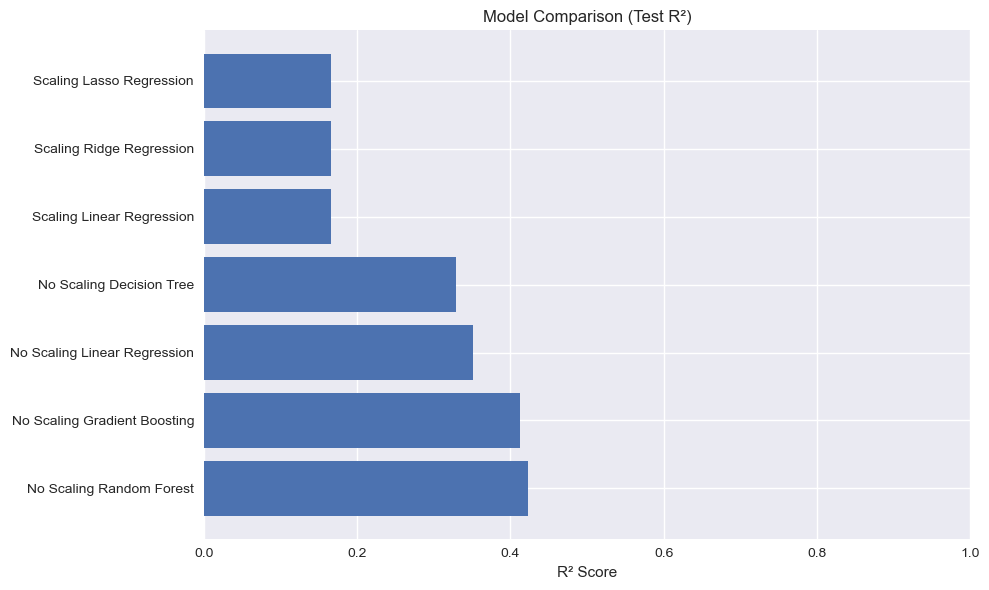

In [36]:
# barplot of model comparison by Test R²
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(result_df['Model'], result_df['Test R²'])

ax.set_xlabel('R² Score')
ax.set_title('Model Comparison (Test R²)')
ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()



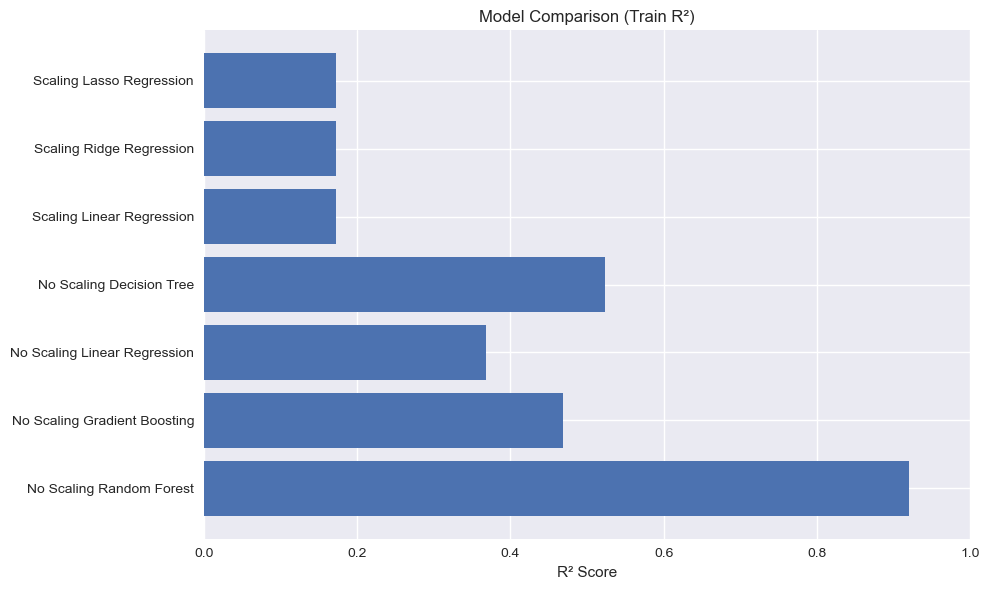

In [37]:
# barplot of model comparison by Train R²
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(result_df['Model'], result_df['Train R²'])

ax.set_xlabel('R² Score')
ax.set_title('Model Comparison (Train R²)')
ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

### Observations

**Best Performer:**

The best performer is Gradient Boosting with the Test R² of 0.4129. It only has a small overfitting gap of 0.0553. The Random Forest has a bit higher Test R² of 0.4235, but it has a severe overfitting gap of 0.4967.


**Models with overfitting:** 

Random Forest and Decision Tree

Random Forest - severe overfitting with Train R² of 0.920 and Test R² of 0.424. The gap is 0.4967.

Decision Tree - moderate overfitting with Train R² of 0.523 and Test R² of 0.329. The gap is 0.1942.


**Models to tune:**

Random Forest, Gradient Boosting, and Decision Tree.


## 3. Cross-Validation
Run 5-fold cross-validation on all models

In [38]:
# Cross-validation

from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=5, shuffle=True, random_state=4950)
cv_results = []


In [39]:
# Linear Regression (Unscaled)
lr_cv = LinearRegression()

scores_lr = cross_val_score(lr_cv, X_train, y_train_capped, cv=cv,scoring='r2',n_jobs=-1)

cv_results.append({'Model': 'Linear Regression (Unscaled)','CV Mean R²': round(scores_lr.mean(), 4),'CV Std': round(scores_lr.std(), 4),
    'Fold 1': round(scores_lr[0], 4),'Fold 2': round(scores_lr[1], 4),'Fold 3': round(scores_lr[2], 4),'Fold 4': round(scores_lr[3], 4),
    'Fold 5': round(scores_lr[4], 4)})


print(f"Linear Regression (Unscaled)     mean={scores_lr.mean():.4f} std={scores_lr.std():.4f}  folds={np.round(scores_lr,3)}")


Linear Regression (Unscaled)     mean=0.3604 std=0.0110  folds=[0.355 0.349 0.378 0.351 0.369]


In [40]:
# Linear Regression (Scaled)
scores_lrs = cross_val_score(lr_cv, X_train_standard, y_train_capped, cv=cv,scoring='r2',n_jobs=-1)

cv_results.append({'Model': 'Linear Regression (Scaled)','CV Mean R²': round(scores_lrs.mean(), 4),'CV Std': round(scores_lrs.std(), 4),
    'Fold 1': round(scores_lrs[0], 4),'Fold 2': round(scores_lrs[1], 4),'Fold 3': round(scores_lrs[2], 4),'Fold 4': round(scores_lrs[3], 4),
    'Fold 5': round(scores_lrs[4], 4)})


print(f"Linear Regression (Scaled)     mean={scores_lrs.mean():.4f} std={scores_lrs.std():.4f}  folds={np.round(scores_lrs,3)}")


Linear Regression (Scaled)     mean=0.1715 std=0.0098  folds=[0.17  0.157 0.185 0.167 0.179]


In [41]:
# Ridge Regression
ridge_cv = Ridge()

scores_rg = cross_val_score(ridge_cv, X_train_standard, y_train_capped, cv=cv,scoring='r2', n_jobs=-1)


cv_results.append({'Model': 'Ridge Regression','CV Mean R²': round(scores_rg.mean(), 4),'CV Std': round(scores_rg.std(), 4),
    'Fold 1': round(scores_rg[0], 4),'Fold 2': round(scores_rg[1], 4),'Fold 3': round(scores_rg[2], 4),'Fold 4': round(scores_rg[3], 4),
    'Fold 5': round(scores_rg[4], 4)})

print(f"Ridge Regression (Scaled)     mean={scores_rg.mean():.4f}  "
      f"std={scores_rg.std():.4f}  folds={np.round(scores_rg,3)}")

Ridge Regression (Scaled)     mean=0.1715  std=0.0098  folds=[0.17  0.157 0.185 0.167 0.179]


In [42]:
# Lasso Regression
lasso_cv = Lasso(alpha=0.01)

scores_ls = cross_val_score(lasso_cv, X_train_standard, y_train_capped, cv=cv,scoring='r2', n_jobs=-1)

cv_results.append({'Model': 'Lasso Regression','CV Mean R²': round(scores_ls.mean(), 4),'CV Std': round(scores_ls.std(), 4),
    'Fold 1': round(scores_ls[0], 4),'Fold 2': round(scores_ls[1], 4),'Fold 3': round(scores_ls[2], 4),'Fold 4': round(scores_ls[3], 4),
    'Fold 5': round(scores_ls[4], 4)})

print(f"Lasso Regression (Scaled)     mean={scores_ls.mean():.4f}  std={scores_ls.std():.4f}  folds={np.round(scores_ls,3)}")

Lasso Regression (Scaled)     mean=0.1715  std=0.0097  folds=[0.17  0.157 0.185 0.167 0.179]


In [43]:
# Decision Tree

dt_cv = DecisionTreeRegressor(max_depth=10, random_state=4950) 

scores_dt = cross_val_score(dt_cv, X_train, y_train_capped, cv=cv,scoring='r2', n_jobs=-1)


cv_results.append({'Model': 'Decision Tree','CV Mean R²': round(scores_dt.mean(), 4),'CV Std': round(scores_dt.std(), 4),
    'Fold 1': round(scores_dt[0], 4),'Fold 2': round(scores_dt[1], 4),'Fold 3': round(scores_dt[2], 4),'Fold 4': round(scores_dt[3], 4),
    'Fold 5': round(scores_dt[4], 4)})

print(f"Decision Tree (Unscaled)     mean={scores_dt.mean():.4f}  std={scores_dt.std():.4f}  folds={np.round(scores_dt,3)}")

Decision Tree (Unscaled)     mean=0.2990  std=0.0103  folds=[0.289 0.304 0.316 0.297 0.289]


In [44]:
# Random Forest
rf_cv = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=4950, n_jobs=-1)

scores_rf = cross_val_score(rf_cv, X_train, y_train_capped, cv=cv,scoring='r2', n_jobs=-1)


cv_results.append({'Model': 'Random Forest','CV Mean R²': round(scores_rf.mean(), 4),'CV Std': round(scores_rf.std(), 4),
    'Fold 1': round(scores_rf[0], 4),'Fold 2': round(scores_rf[1], 4),'Fold 3': round(scores_rf[2], 4),'Fold 4': round(scores_rf[3], 4),
    'Fold 5': round(scores_rf[4], 4)})

print(f"Random Forest (Unscaled)     mean={scores_rf.mean():.4f}  std={scores_rf.std():.4f}  folds={np.round(scores_rf,3)}")


Random Forest (Unscaled)     mean=0.4248  std=0.0217  folds=[0.392 0.418 0.46  0.425 0.429]


In [45]:
# Gradient Boosting
gb_cv = GradientBoostingRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=4950)

scores_gb = cross_val_score(gb_cv, X_train, y_train_capped, cv=cv,scoring='r2', n_jobs=-1)

cv_results.append({'Model': 'Gradient Boosting','CV Mean R²': round(scores_gb.mean(), 4),'CV Std': round(scores_gb.std(), 4),
    'Fold 1': round(scores_gb[0], 4),'Fold 2': round(scores_gb[1], 4), 'Fold 3': round(scores_gb[2], 4),'Fold 4': round(scores_gb[3], 4),
    'Fold 5': round(scores_gb[4], 4)})

print(f"Gradient Boosting (Unscaled)     mean={scores_gb.mean():.4f}  std={scores_gb.std():.4f}  folds={np.round(scores_gb,3)}")


Gradient Boosting (Unscaled)     mean=0.4221  std=0.0146  folds=[0.413 0.402 0.444 0.42  0.432]


In [46]:
# Summary DataFrame
cv_df = pd.DataFrame(cv_results).sort_values('CV Mean R²', ascending=False).reset_index(drop=True)
print(cv_df.to_string(index=False))

                       Model  CV Mean R²  CV Std  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5
               Random Forest      0.4248  0.0217  0.3925  0.4177  0.4600  0.4252  0.4286
           Gradient Boosting      0.4221  0.0146  0.4128  0.4022  0.4442  0.4196  0.4316
Linear Regression (Unscaled)      0.3604  0.0110  0.3552  0.3491  0.3779  0.3515  0.3685
               Decision Tree      0.2990  0.0103  0.2886  0.3044  0.3162  0.2966  0.2893
  Linear Regression (Scaled)      0.1715  0.0098  0.1702  0.1568  0.1847  0.1666  0.1791
            Ridge Regression      0.1715  0.0098  0.1702  0.1568  0.1847  0.1666  0.1791
            Lasso Regression      0.1715  0.0097  0.1702  0.1568  0.1847  0.1666  0.1791


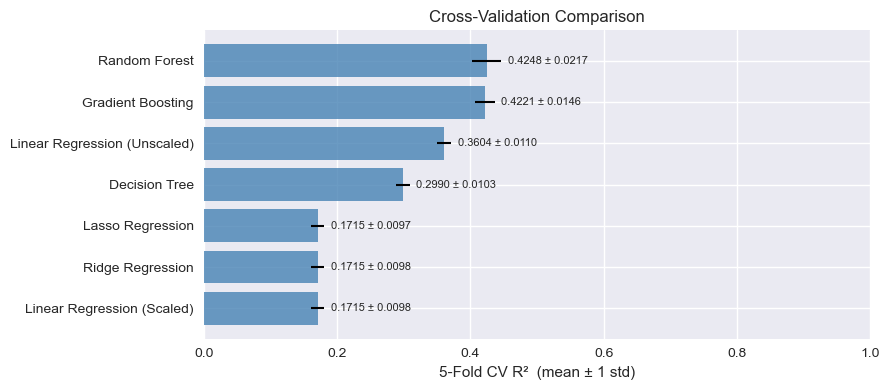

In [47]:
# Visualise CV mean ± 1 std
cv_df = pd.DataFrame(cv_results).sort_values('CV Mean R²', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(cv_df['Model'], cv_df['CV Mean R²'],
        xerr=cv_df['CV Std'], color='steelblue', alpha=0.8,
        error_kw=dict(ecolor='black', capsize=5, lw=1.5))
ax.set_xlabel('5-Fold CV R²  (mean ± 1 std)')
ax.set_title('Cross-Validation Comparison')
ax.set_xlim(0, 1.0)
for i, row in cv_df.iterrows():
    ax.text(row['CV Mean R²'] + row['CV Std'] + 0.01,
            list(cv_df.index).index(i),
            f"{row['CV Mean R²']:.4f} ± {row['CV Std']:.4f}",
            va='center', fontsize=8)
plt.tight_layout()
plt.show()


### Observations


**CV Mean and Test set results:**

CV means are very consistent with the test R² scores.

Random Forest results are almost identical. It has a CV Mean of 0.4248 while Test R² is 0.4235. 

Gradient Boosting results are very close. It has a CV Mean of 0.4221 while Test R² is 0.4129.

Unscaled Linear Regression results are close. It has a CV Mean of 0.3604 while Test R² is 0.3514.

Decision Tree results are slightly different. It has a CV Mean 0.2990 while Test R² is 0.3287.

Scaled Linear Regression results are close. It has a CV Mean of 0.1715 while Test R² is 0.1662.


**Models with CV Std > 0.03:**

All seven models have CV Std below 0.03. There are no potentially unstable models. Gradient Boosting has the lowest std (0.0146), making it the most consistent performer across all folds.


| Model | CV Std | 
| -------- | -------- |
| Linear Regression (Unscaled) | 0.0110 | 
| Linear Regression (Scaled) | 0.0098 | 
| Ridge Regression | 0.0098 |
| Lasso Regression | 0.0097 |
| Decision Tree | 0.0103 |
| Random Forest | 0.0217 |
| Gradient Boosting | 0.0146 |          


## 4. Hyperparameter Tuning - GridSearchCV

## 5. Final Model Comparison

## 6. Save Best Model

## Key Finding